In [1]:
import os
import random
import pickle
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

CSV_PATH = "data/dataset_processed.csv" 
TFIDF_MAX_FEATURES = 10000
SVD_COMPONENTS = 300
TRAIN_VAL_SPLIT = 0.2
BATCH_SIZE = 256
EPOCHS_SUPERVISED = 8
EMBEDDING_DIM = 64
TRIPLET_SAMPLE_SIZE = 50000

In [2]:
df = pd.read_csv(CSV_PATH)

In [3]:
numeric_cols = [
    "valence","acousticness","danceability","energy","instrumentalness",
    "liveness","loudness","speechiness","tempo","duration_sec","popularity"
]

categorical_cols = ["artists", "language", "decade", "mode", "key", "explicit"]
text_col = "tokens"

df[numeric_cols] = df[numeric_cols].fillna(0.0)
df[text_col] = df[text_col].fillna("")
df[categorical_cols] = df[categorical_cols].fillna("NA")


In [4]:
def clean_artist_field(x):
    s = str(x)
    if s.startswith("[") and s.endswith("]"):
        s2 = s.strip()[1:-1].strip()
        s2 = s2.replace("'", "").replace('"', '')
        first = s2.split(",")[0].strip()
        return first
    return s

sample0 = str(df["artists"].iloc[0])
if sample0.startswith("[") and sample0.endswith("]"):
    print("Limpiando campo 'artists' de formato lista-string...")
    df["artists"] = df["artists"].apply(clean_artist_field)
else:
    print("'artists' no parece lista-string, no se modifica.")

# LabelEncode
label_encoders = {}
X_cat = {}
cat_cardinalities = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    le.fit(df[col].values)
    label_encoders[col] = le
    X_cat[col] = le.transform(df[col].values)
    cat_cardinalities[col] = len(le.classes_)
    print(f"Col: {col}  -> categorías: {cat_cardinalities[col]}")

cat_cols_ordered = categorical_cols


Limpiando campo 'artists' de formato lista-string...
Col: artists  -> categorías: 7174
Col: language  -> categorías: 2
Col: decade  -> categorías: 7
Col: mode  -> categorías: 2
Col: key  -> categorías: 12
Col: explicit  -> categorías: 2


In [5]:
scaler = MinMaxScaler()
X_num = scaler.fit_transform(df[numeric_cols].values)
print("X_num shape:", X_num.shape)

X_num shape: (28608, 11)
 (28608, 11)


In [6]:
print("Construyendo TF-IDF (max_features=%d)..." % TFIDF_MAX_FEATURES)
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1,2), min_df=2)
X_text_tfidf = tfidf.fit_transform(df[text_col].astype(str).values)
print("TF-IDF shape:", X_text_tfidf.shape)

n_components = min(SVD_COMPONENTS, X_text_tfidf.shape[1]-1)
print("Reduciendo TF-IDF a %d componentes con TruncatedSVD..." % n_components)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)
X_text = svd.fit_transform(X_text_tfidf)
print("X_text shape (SVD):", X_text.shape)

Construyendo TF-IDF (max_features=10000)...


TF-IDF shape: (28608, 10000)
Reduciendo TF-IDF a 300 componentes con TruncatedSVD...
X_text shape (SVD): (28608, 300)
X_text shape (SVD): (28608, 300)


In [7]:
for col in cat_cols_ordered:
    arr = X_cat[col]
    print(col, "-> shape:", arr.shape, " sample:", arr[:3])

sample_idx = 0
print("\nEjemplo (fila 0) tamaños:")
print(" X_num:", X_num[sample_idx].shape)
print(" X_text:", X_text[sample_idx].shape)
for col in cat_cols_ordered:
    print(f" {col} (int):", X_cat[col][sample_idx])


artists -> shape: (28608,)  sample: [1996 1996 1920]
language -> shape: (28608,)  sample: [0 0 0]
decade -> shape: (28608,)  sample: [0 0 0]
mode -> shape: (28608,)  sample: [1 0 1]
key -> shape: (28608,)  sample: [7 4 1]
explicit -> shape: (28608,)  sample: [0 0 0]

Ejemplo (fila 0) tamaños:
 X_num: (11,)
 X_text: (300,)
 artists (int): 1996
 language (int): 0
 decade (int): 0
 mode (int): 1
 key (int): 7
 explicit (int): 0


In [8]:
y = df["was_trending"].fillna(0).astype(int).values

stratify_param = y if len(np.unique(y)) > 1 and np.min(np.bincount(y)) > 5 else None

indices = np.arange(len(df))
idx_train, idx_val = train_test_split(indices, test_size=TRAIN_VAL_SPLIT, random_state=RANDOM_SEED, stratify=stratify_param)

print("Tamaños: train =", len(idx_train), " val =", len(idx_val))
print("Positivos train/val:", y[idx_train].sum(), y[idx_val].sum())

def build_input_dict(idx_array):
    inputs = {
        "numeric_input": X_num[idx_array],
        "text_input": X_text[idx_array]
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col][idx_array]
    return inputs

train_inputs = build_input_dict(idx_train)
val_inputs = build_input_dict(idx_val)
y_train = y[idx_train]
y_val = y[idx_val]

print("Train inputs prepared. Ejemplo shapes:")
for k,v in train_inputs.items():
    print(" ", k, "->", getattr(v, "shape", None))
print("y_train shape:", y_train.shape)

Tamaños: train = 22886  val = 5722
Positivos train/val: 5722 1430
Train inputs prepared. Ejemplo shapes:
  numeric_input -> (22886, 11)
  text_input -> (22886, 300)
  artists_input -> (22886,)
  language_input -> (22886,)
  decade_input -> (22886,)
  mode_input -> (22886,)
  key_input -> (22886,)
  explicit_input -> (22886,)
y_train shape: (22886,)


In [9]:
assert X_num.shape[0] == len(df)
assert X_text.shape[0] == len(df)
for col in cat_cols_ordered:
    assert X_cat[col].shape[0] == len(df)

**Arquitectura Multimodelo**

In [12]:
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2

ARTIST_WEIGHT = 16.0
EMBEDDING_DIM = 64
DROPOUT_RATE = 0.4
L2_REG = 3e-4

numeric_in = layers.Input(shape=(X_num.shape[1],), name="numeric_input")
text_in    = layers.Input(shape=(X_text.shape[1],), name="text_input")

num_feat  = layers.GaussianNoise(0.01)(numeric_in)
text_feat = layers.GaussianNoise(0.01)(text_in)

cat_inputs = {}
cat_embs = []
artist_emb_index = None

for i, col in enumerate(cat_cols_ordered):
    inp = layers.Input(shape=(1,), dtype="int32", name=f"{col}_input")
    cat_inputs[col] = inp

    vocab = int(cat_cardinalities[col]) + 1
    emb_dim = min(50, max(4, int(1 + np.log2(max(2, cat_cardinalities[col])) * 4)))

    emb = layers.Embedding(
        input_dim=vocab,
        output_dim=emb_dim,
        embeddings_regularizer=l2(L2_REG),
        name=f"{col}_emb"
    )(inp)
    emb = layers.Flatten()(emb)
    emb = layers.Dropout(0.25)(emb)
    emb = layers.GaussianNoise(0.01)(emb)

    cat_embs.append(emb)

    if col == "artists":
        artist_emb_index = i

concat = layers.Concatenate(name="concat_features")(
    [num_feat, text_feat] + cat_embs
)

x = layers.Dense(512, activation="relu", kernel_regularizer=l2(L2_REG), name="dense_1")(concat)
x = layers.BatchNormalization(name="batch_norm_1")(x)
x = layers.Dropout(DROPOUT_RATE, name="dropout_1")(x)

x = layers.Dense(256, activation="relu", kernel_regularizer=l2(L2_REG), name="dense_2")(x)
x = layers.BatchNormalization(name="batch_norm_2")(x)
x = layers.Dropout(DROPOUT_RATE, name="dropout_2")(x)

x = layers.Dense(128, activation="relu", kernel_regularizer=l2(L2_REG), name="dense_3")(x)
x = layers.BatchNormalization(name="batch_norm_3")(x)

res = layers.Dense(128, activation="linear", kernel_regularizer=l2(L2_REG), name="res_proj")(concat)
x = layers.Add(name="residual_add")([x, res])
x = layers.Dropout(DROPOUT_RATE/2, name="dropout_3")(x)

embedding_raw = layers.Dense(
    EMBEDDING_DIM,
    activation="linear",
    kernel_regularizer=l2(L2_REG),
    name="embedding_raw"
)(x)

artist_emb = cat_embs[artist_emb_index]
artist_strength = layers.Dense(
    EMBEDDING_DIM,
    activation="linear",
    kernel_regularizer=l2(L2_REG),
    name="artist_strength"
)(artist_emb)
artist_strength = layers.Lambda(lambda t: t * ARTIST_WEIGHT, name="artist_boost")(artist_strength)
embedding_raw = layers.Add(name="add_artist_boost")([embedding_raw, artist_strength])

embedding = layers.Lambda(lambda t: K.l2_normalize(t, axis=1), name="embedding")(embedding_raw)

trend_head = layers.Dense(64, activation="relu", kernel_regularizer=l2(L2_REG), name="trend_dense_1")(x)
trend_head = layers.Dropout(0.2, name="trend_dropout_1")(trend_head)
trend_head = layers.Dense(32, activation="relu", kernel_regularizer=l2(L2_REG), name="trend_dense_2")(trend_head)
trend_head = layers.Dropout(0.1, name="trend_dropout_2")(trend_head)

trend_logit = layers.Dense(1, activation="linear", kernel_regularizer=l2(L2_REG), name="trend_logit")(trend_head)

def map_to_range_02_09(x):
    tanh_out = K.tanh(x * 0.5)
    return 0.55 + 0.35 * tanh_out

trend_output = layers.Lambda(map_to_range_02_09, name="trend_output")(trend_logit)

model = Model(
    inputs=[numeric_in, text_in] + list(cat_inputs.values()),
    outputs=[embedding, trend_output]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ artists_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ language_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decade_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mode_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ key_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ explicit_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ artists_emb         │ (None, 1, 50)     │    358,750 │ artists_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ language_emb        │ (None, 1, 5)      │         15 │ language_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decade_emb          │ (None, 1, 12)     │         96 │ decade_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mode_emb            │ (None, 1, 5)      │         15 │ mode_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ key_emb (Embedding) │ (None, 1, 15)     │        195 │ key_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ explicit_emb        │ (None, 1, 5)      │         15 │ explicit_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 50)        │          0 │ artists_emb[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 5)         │          0 │ language_emb[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 12)        │          0 │ decade_emb[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 5)         │          0 │ mode_emb[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 15)        │          0 │ key_emb[0][0]     │
│ (Flatten)           │                   │            │                 

 Total params: 807,343 (3.08 MB)

 Trainable params: 805,551 (3.07 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [13]:
def custom_trend_loss(y_true, y_pred):
    y_true_scaled = 0.2 + 0.7 * y_true
    
    return K.mean(K.square(y_pred - y_true_scaled))

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "embedding": "mse",
        "trend_output": custom_trend_loss
    },
    loss_weights={
        "embedding": 0.0,
        "trend_output": 1.0
    },
    metrics={"trend_output": ["mae"]}
)

In [ ]:
sample_idx = np.arange(min(8, len(df)))
check_inputs = build_input_dict(sample_idx)

outs = model.predict(check_inputs, batch_size=8)
emb_check, trend_check = outs[0], outs[1]
print("Embedding shape (batch):", emb_check.shape)
print("Trend preds shape (batch):", trend_check.shape)
print("Ejemplo trend probs:", trend_check.ravel())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
Embedding shape (batch): (8, 64)
Trend preds shape (batch): (8, 1)
Ejemplo trend probs: [0.5487277  0.54993546 0.5407619  0.53876173 0.52793926 0.54630005
 0.5451878  0.52841085]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
Embedding shape (batch): (8, 64)
Trend preds shape (batch): (8, 1)
Ejemplo trend probs: [0.5487277  0.54993546 0.5407619  0.53876173 0.52793926 0.54630005
 0.5451878  0.52841085]


In [14]:
def build_input_dict_from_indices(idx_array):
    return build_input_dict(np.array(idx_array, dtype=int))

def inputs_for_all():
    inputs = {
        "numeric_input": X_num,
        "text_input": X_text
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col]
    return inputs

**Entrenamiento**

In [15]:
def build_input_dict(idx_array):
    inputs = {
        "numeric_input": X_num[idx_array],
        "text_input": X_text[idx_array]
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col][idx_array]
    return inputs

train_inputs = build_input_dict(idx_train)
val_inputs = build_input_dict(idx_val)


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

EPOCHS_SUPERVISED = 100 
BATCH_SIZE = 256

callbacks = [
    EarlyStopping(
        monitor='val_trend_output_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_trend_output_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'models/best_model.h5',
        monitor='val_trend_output_mae',  # Cambio: MAE en lugar de accuracy
        save_best_only=True,
        verbose=1,
        mode='min'  # Cambio: min en lugar de max para MAE
    )
]

os.makedirs("models", exist_ok=True)

history = model.fit(
    train_inputs,
    {
        "embedding": np.zeros((len(idx_train), EMBEDDING_DIM)),
        "trend_output": y_train
    },
    validation_data=(
        val_inputs,
        {
            "embedding": np.zeros((len(idx_val), EMBEDDING_DIM)),
            "trend_output": y_val
        }
    ),
    epochs=EPOCHS_SUPERVISED,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - embedding_loss: 0.0156 - loss: 0.4566 - trend_output_loss: 0.0555 - trend_output_mae: 0.3346
Epoch 1: val_trend_output_mae improved from None to 0.34950, saving model to models/best_model.h5

Epoch 1: val_trend_output_mae improved from None to 0.34950, saving model to models/best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - embedding_loss: 0.0156 - loss: 0.3621 - trend_output_loss: 0.0373 - trend_output_mae: 0.2847 - val_embedding_loss: 0.0156 - val_loss: 0.3255 - val_trend_output_loss: 0.1064 - val_trend_output_mae: 0.3495 - learning_rate: 0.0010
Epoch 2/100
Epoch 2/100
88/90 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - embedding_loss: 0.0156 - loss: 0.2127 - trend_output_loss: 0.0191 - trend_output_mae: 0.2318
Epoch 2: val_trend_output_mae improved from 0.34950 to 0.34906, saving model to models/best_model.h5

Epoch 2: val_trend_output_mae improved from 0.34950 to 0.34906, saving model to models/best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - embedding_loss: 0.0156 - loss: 0.1894 - trend_output_loss: 0.0182 - trend_output_mae: 0.2293 - val_embedding_loss: 0.0156 - val_loss: 0.2461 - val_trend_output_loss: 0.1142 - val_trend_output_mae: 0.3491 - learning_rate: 0.0010
Epoch 3/100
Epoch 3/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - embedding_loss: 0.0156 - loss: 0.1332 - trend_output_loss: 0.0152 - trend_output_mae: 0.2223
Epoch 3: val_trend_output_mae improved from 0.34906 to 0.34747, saving model to models/best_model.h5

Epoch 3: val_trend_output_mae improved from 0.34906 to 0.34747, saving model to models/best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - embedding_loss: 0.0156 - loss: 0.1203 - trend_output_loss: 0.0145 - trend_output_mae: 0.2203 - val_embedding_loss: 0.0156 - val_loss: 0.1961 - val_trend_output_loss: 0.1125 - val_trend_output_mae: 0.3475 - learning_rate: 0.0010
Epoch 4/100
Epoch 4/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - embedding_loss: 0.0156 - loss: 0.0875 - trend_output_loss: 0.0122 - trend_output_mae: 0.2150
Epoch 4: val_trend_output_mae improved from 0.34747 to 0.33782, saving model to models/best_model.h5

Epoch 4: val_trend_output_mae improved from 0.34747 to 0.33782, saving model to models/best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - embedding_loss: 0.0156 - loss: 0.0802 - trend_output_loss: 0.0122 - trend_output_mae: 0.2144 - val_embedding_loss: 0.0156 - val_loss: 0.1586 - val_trend_output_loss: 0.1037 - val_trend_output_mae: 0.3378 - learning_rate: 0.0010
Epoch 5/100
Epoch 5/100
88/90 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - embedding_loss: 0.0156 - loss: 0.0611 - trend_output_loss: 0.0116 - trend_output_mae: 0.2130
Epoch 5: val_trend_output_mae improved from 0.33782 to 0.30057, saving model to models/best_model.h5

Epoch 5: val_trend_output_mae improved from 0.33782 to 0.30057, saving model to models/best_model.h5


...

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - embedding_loss: 0.0156 - loss: 0.0324 - trend_output_loss: 0.0095 - trend_output_mae: 0.2078 - val_embedding_loss: 0.0156 - val_loss: 0.0344 - val_trend_output_loss: 0.0143 - val_trend_output_mae: 0.2193 - learning_rate: 0.0010
Epoch 8/100
Epoch 8/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - embedding_loss: 0.0156 - loss: 0.0286 - trend_output_loss: 0.0096 - trend_output_mae: 0.2085
Epoch 8: val_trend_output_mae improved from 0.21931 to 0.20995, saving model to models/best_model.h5

Epoch 8: val_trend_output_mae improved from 0.21931 to 0.20995, saving model to models/best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - embedding_loss: 0.0156 - loss: 0.0277 - trend_output_loss: 0.0096 - trend_output_mae: 0.2088 - val_embedding_loss: 0.0156 - val_loss: 0.0262 - val_trend_output_loss: 0.0096 - val_trend_output_mae: 0.2100 - learning_rate: 0.0010
Epoch 9/100
Epoch 9/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - embedding_loss: 0.0156 - loss: 0.0239 - trend_output_loss: 0.0084 - trend_output_mae: 0.2046
Epoch 9: val_trend_output_mae did not improve from 0.20995
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - embedding_loss: 0.0156 - loss: 0.0236 - trend_output_loss: 0.0086 - trend_output_mae: 0.2048 - val_embedding_loss: 0.0142 - val_loss: 0.0252 - val_trend_output_loss: 0.0108 - val_trend_output_mae: 0.2120 - learning_rate: 0.0010
Epoch 10/100

Epoch 9: val_trend_output_mae did not improve from 0.20995
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - embedding_loss: 0.0156 - loss: 0.0236 - trend_output_loss: 0.0086 - trend_output_mae: 0.2048 - val_embedding_loss: 0.0142 - val

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - embedding_loss: 0.0155 - loss: 0.0208 - trend_output_loss: 0.0083 - trend_output_mae: 0.2043 - val_embedding_loss: 0.0053 - val_loss: 0.0229 - val_trend_output_loss: 0.0102 - val_trend_output_mae: 0.2066 - learning_rate: 0.0010
Epoch 12/100
Epoch 12/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - embedding_loss: 0.0084 - loss: 0.0208 - trend_output_loss: 0.0084 - trend_output_mae: 0.2045
Epoch 12: val_trend_output_mae did not improve from 0.20662
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - embedding_loss: 0.0044 - loss: 0.0209 - trend_output_loss: 0.0085 - trend_output_mae: 0.2053 - val_embedding_loss: 8.2692e-05 - val_loss: 0.0279 - val_trend_output_loss: 0.0152 - val_trend_output_mae: 0.2138 - learning_rate: 0.0010
Epoch 13/100

Epoch 12: val_trend_output_mae did not improve from 0.20662
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - embedding_loss: 0.0044 - loss: 0.0209 - trend_output_loss: 0.0085 - trend_output_mae: 0.2053 - val_embedding_loss: 8.26

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - embedding_loss: 7.5286e-07 - loss: 0.0184 - trend_output_loss: 0.0075 - trend_output_mae: 0.2029 - val_embedding_loss: 5.5094e-08 - val_loss: 0.0196 - val_trend_output_loss: 0.0091 - val_trend_output_mae: 0.2065 - learning_rate: 5.0000e-04
Epoch 15/100
Epoch 15/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - embedding_loss: 1.1781e-07 - loss: 0.0173 - trend_output_loss: 0.0073 - trend_output_mae: 0.2025
Epoch 15: val_trend_output_mae did not improve from 0.20647
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - embedding_loss: 7.2754e-08 - loss: 0.0170 - trend_output_loss: 0.0074 - trend_output_mae: 0.2022 - val_embedding_loss: 4.3929e-09 - val_loss: 0.0222 - val_trend_output_loss: 0.0128 - val_trend_output_mae: 0.2107 - learning_rate: 5.0000e-04
Epoch 16/100

Epoch 15: val_trend_output_mae did not improve from 0.20647
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - embedding_loss: 7.2754e-08 - loss: 0.0170 - trend_output_loss: 0.0074 - trend_output_mae: 0.202

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - embedding_loss: 9.3837e-14 - loss: 0.0126 - trend_output_loss: 0.0058 - trend_output_mae: 0.1977 - val_embedding_loss: 7.2779e-15 - val_loss: 0.0166 - val_trend_output_loss: 0.0098 - val_trend_output_mae: 0.2058 - learning_rate: 2.5000e-04
Epoch 21/100
Epoch 21/100
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - embedding_loss: 2.8139e-14 - loss: 0.0124 - trend_output_loss: 0.0059 - trend_output_mae: 0.1989
Epoch 21: val_trend_output_mae did not improve from 0.20575
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - embedding_loss: 1.9905e-14 - loss: 0.0121 - trend_output_loss: 0.0058 - trend_output_mae: 0.1979 - val_embedding_loss: 1.3920e-15 - val_loss: 0.0189 - val_trend_output_loss: 0.0124 - val_trend_output_mae: 0.2085 - learning_rate: 2.5000e-04
Epoch 22/100

Epoch 21: val_trend_output_mae did not improve from 0.20575
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - embedding_loss: 1.9905e-14 - loss: 0.0121 - trend_output_loss: 0.0058 - trend_output_mae: 0.197

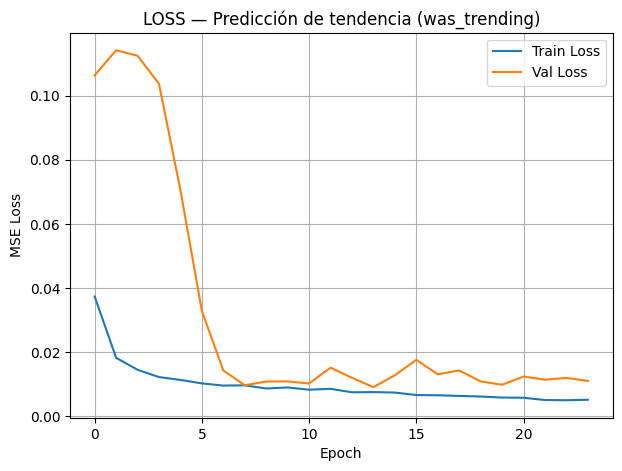

In [17]:
import matplotlib.pyplot as plt

train_loss = history.history.get("trend_output_loss", history.history["loss"])
val_loss   = history.history.get("val_trend_output_loss", history.history["val_loss"])

plt.figure(figsize=(7,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("LOSS — Predicción de tendencia (was_trending)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

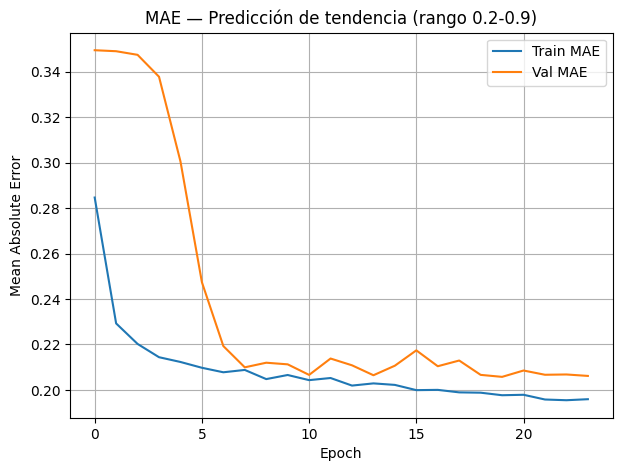

In [18]:
mae_key      = "trend_output_mae"
val_mae_key  = "val_trend_output_mae"

train_mae = history.history[mae_key]
val_mae   = history.history[val_mae_key]

plt.figure(figsize=(7,5))
plt.plot(train_mae, label="Train MAE")
plt.plot(val_mae, label="Val MAE")
plt.title("MAE — Predicción de tendencia (rango 0.2-0.9)")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

embedding_val, trend_pred_val = model.predict(val_inputs, verbose=0)

trend_pred_val = trend_pred_val.flatten()

print("Rango de predicciones:", f"{trend_pred_val.min():.3f} - {trend_pred_val.max():.3f}")
print("Predicciones ejemplo:", trend_pred_val[:10])

th = 0.55
y_pred_bin = (trend_pred_val >= th).astype(int)
cm = confusion_matrix(y_val, y_pred_bin)
print(f"\nThreshold (rango 0.2-0.9): {th}")
print("\nClassification report:\n", classification_report(y_val, y_pred_bin, digits=4))

Rango de predicciones: 0.204 - 0.900
Predicciones ejemplo: [0.8999841  0.20677122 0.20656681 0.21976027 0.21008876 0.3744483
 0.8997911  0.20683655 0.20757857 0.20712212]

Threshold (rango 0.2-0.9): 0.55

Classification report:
               precision    recall  f1-score   support

           0     0.9759    0.9902    0.9830      4292
           1     0.9693    0.9266    0.9474      1430

    accuracy                         0.9743      5722
   macro avg     0.9726    0.9584    0.9652      5722
weighted avg     0.9742    0.9743    0.9741      5722



In [21]:
def inputs_for_all():
    inputs = {
        "numeric_input": X_num,
        "text_input": X_text
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col]
    return inputs

all_inputs = inputs_for_all()

outs_all = model.predict(all_inputs, batch_size=512, verbose=1)

embeddings_all = outs_all[0]
trend_preds_all = outs_all[1].ravel()

trending_threshold = 0.55
trending_count = (trend_preds_all >= trending_threshold).sum()

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [22]:
import pickle

os.makedirs("models", exist_ok=True)
EXPORT_PKL = "models/recommender.pkl"

export_obj = {
    "model_weights": model.get_weights(),
    "model_config": {
        "numeric_dim": X_num.shape[1],
        "text_dim": X_text.shape[1],
        "categorical_cols": cat_cols_ordered,
        "cat_cardinalities": {col: int(len(label_encoders[col].classes_)) for col in cat_cols_ordered},
        "embedding_dim": EMBEDDING_DIM
    },

    "scaler": scaler,
    "tfidf": tfidf,
    "svd": svd,
    "label_encoders": label_encoders,

    "embeddings": embeddings_all,
    "trend_preds": trend_preds_all,
    "ids": df["id"].tolist(),
    "names": df["name"].tolist(),
    "trend_labels": df["was_trending"].tolist(),
    "numeric_cols": numeric_cols,
    "categorical_cols": cat_cols_ordered,
    "text_col": text_col
}

with open(EXPORT_PKL, "wb") as f:
    pickle.dump(export_obj, f)

print("Exportado a", EXPORT_PKL, "con keys:", list(export_obj.keys()))

Exportado a models/recommender.pkl con keys: ['model_weights', 'model_config', 'scaler', 'tfidf', 'svd', 'label_encoders', 'embeddings', 'trend_preds', 'ids', 'names', 'trend_labels', 'numeric_cols', 'categorical_cols', 'text_col']


In [23]:
import pickle
import numpy as np
from tensorflow.keras import layers, Model

# Cargar pkl
with open("models/recommender.pkl", "rb") as f:
    data = pickle.load(f)

model_config = data["model_config"]
model_weights = data["model_weights"]

scaler           = data["scaler"]
tfidf            = data["tfidf"]
svd              = data["svd"]
label_encoders   = data["label_encoders"]

ids              = data["ids"]
names            = data["names"]
embeddings_all   = data["embeddings"]
trend_labels     = data["trend_labels"]

In [26]:
from tensorflow.keras.regularizers import l2

ARTIST_WEIGHT = 16.0
DROPOUT_RATE = 0.4
L2_REG = 3e-4

numeric_dim = model_config["numeric_dim"]
text_dim = model_config["text_dim"]
cat_cols = model_config["categorical_cols"]
cat_cards = model_config["cat_cardinalities"]
embedding_dim = model_config["embedding_dim"]

numeric_in = layers.Input(shape=(numeric_dim,), name="numeric_input")
text_in = layers.Input(shape=(text_dim,), name="text_input")

num_feat = layers.GaussianNoise(0.01)(numeric_in)
text_feat = layers.GaussianNoise(0.01)(text_in)

cat_inputs = {}
cat_embs = []
artist_emb_index = None

for i, col in enumerate(cat_cols):
    inp = layers.Input(shape=(1,), dtype="int32", name=f"{col}_input")
    cat_inputs[col] = inp
    
    vocab = int(cat_cards[col]) + 1
    emb_dim = min(50, max(4, int(1 + np.log2(max(2, cat_cards[col])) * 4)))
    
    emb = layers.Embedding(
        input_dim=vocab,
        output_dim=emb_dim,
        embeddings_regularizer=l2(L2_REG),
        name=f"{col}_emb"
    )(inp)
    emb = layers.Flatten()(emb)
    emb = layers.Dropout(0.25)(emb)
    emb = layers.GaussianNoise(0.01)(emb)
    
    cat_embs.append(emb)
    
    if col == "artists":
        artist_emb_index = i

concat = layers.Concatenate(name="concat_features")(
    [num_feat, text_feat] + cat_embs
)

x = layers.Dense(512, activation="relu", kernel_regularizer=l2(L2_REG), name="dense_1")(concat)
x = layers.BatchNormalization(name="batch_norm_1")(x)
x = layers.Dropout(DROPOUT_RATE, name="dropout_1")(x)

x = layers.Dense(256, activation="relu", kernel_regularizer=l2(L2_REG), name="dense_2")(x)
x = layers.BatchNormalization(name="batch_norm_2")(x)
x = layers.Dropout(DROPOUT_RATE, name="dropout_2")(x)

x = layers.Dense(128, activation="relu", kernel_regularizer=l2(L2_REG), name="dense_3")(x)
x = layers.BatchNormalization(name="batch_norm_3")(x)

res = layers.Dense(128, activation="linear", kernel_regularizer=l2(L2_REG), name="res_proj")(concat)
x = layers.Add(name="residual_add")([x, res])
x = layers.Dropout(DROPOUT_RATE/2, name="dropout_3")(x)

embedding_raw = layers.Dense(
    embedding_dim,
    activation="linear",
    kernel_regularizer=l2(L2_REG),
    name="embedding_raw"
)(x)

artist_emb = cat_embs[artist_emb_index]
artist_strength = layers.Dense(
    embedding_dim,
    activation="linear",
    kernel_regularizer=l2(L2_REG),
    name="artist_strength"
)(artist_emb)
artist_strength = layers.Lambda(lambda t: t * ARTIST_WEIGHT, name="artist_boost")(artist_strength)
embedding_raw = layers.Add(name="add_artist_boost")([embedding_raw, artist_strength])

embedding = layers.Lambda(lambda t: K.l2_normalize(t, axis=1), name="embedding")(embedding_raw)

trend_head = layers.Dense(64, activation="relu", kernel_regularizer=l2(L2_REG), name="trend_dense_1")(x)
trend_head = layers.Dropout(0.2, name="trend_dropout_1")(trend_head)
trend_head = layers.Dense(32, activation="relu", kernel_regularizer=l2(L2_REG), name="trend_dense_2")(trend_head)
trend_head = layers.Dropout(0.1, name="trend_dropout_2")(trend_head)

trend_logit = layers.Dense(1, activation="linear", kernel_regularizer=l2(L2_REG), name="trend_logit")(trend_head)

def map_to_range_02_09(x):
    tanh_out = K.tanh(x * 0.5)
    return 0.55 + 0.35 * tanh_out

trend_output = layers.Lambda(map_to_range_02_09, name="trend_output")(trend_logit)

model = Model(
    inputs=[numeric_in, text_in] + list(cat_inputs.values()),
    outputs=[embedding, trend_output]
)

model.set_weights(model_weights)

print("Modelo COMPLETO reconstruido y pesos cargados.")

Modelo COMPLETO reconstruido y pesos cargados.


In [27]:
def build_input_single(row):
    num = scaler.transform([row[numeric_cols]])[0]
    text = svd.transform(tfidf.transform([str(row["tokens"])]))[0]

    inputs = {
        "numeric_input": np.array([num]),
        "text_input": np.array([text])
    }
    for col in cat_cols:
        encoded = label_encoders[col].transform([str(row[col])])
        inputs[f"{col}_input"] = np.array(encoded).reshape(1,1)
    return inputs

row0 = df.iloc[3254]
inputs0 = build_input_single(row0)
_, pred_trending = model.predict(inputs0)

print("Canción:", row0["name"])
print("Probabilidad de ser trending:", f"{pred_trending[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
Canción: Circles
Probabilidad de ser trending: 0.9000
Canción: Circles
Probabilidad de ser trending: 0.9000


In [28]:
from scipy.spatial.distance import cdist

def recommend(song_id, k=5):
    if song_id not in ids:
        raise ValueError("ID no encontrado.")
        
    idx = ids.index(song_id)
    vec = embeddings_all[idx].reshape(1,-1)

    dists = cdist(vec, embeddings_all, metric="cosine")[0]
    sims = 1 - dists

    sims[idx] = -999

    top = sims.argsort()[::-1][:k]
    results = [(ids[i], names[i], float(sims[i])) for i in top]
    return results

song_id = ids[3254]
print("Recomendaciones basadas en:", names[3254])
for r in recommend(song_id, k=10):
    print(r)


Recomendaciones basadas en: Circles
('1D2L6MefbXon28PzIk9I3r', '92 Explorer', 0.9999999999989876)
('7dt6x5M1jzdTEt8oCbisTK', 'Better Now', 0.9999999999918946)
('5lZZmityu9TAjNvSY6GLhR', 'Zack And Codeine', 0.9999999999908585)
('32lItqlMi4LBhb4k0BaSaC', 'Candy Paint', 0.9999999999906463)
('1YscJ7yVTlFxW3eF6pv5ba', 'Allergic', 0.9999999999901048)
('5DLTuH4A5VZB2HKpqHQR6t', 'Patient', 0.9999999999893768)
('6M0IsaUX4GNyto4niSegfI', 'No Option', 0.9999999999880751)
('05mDaV9Vb3wrzjF6OPZnhq', 'Saint-Tropez', 0.9999999999841754)
('0H8XeaJunhvpBdBFIYi6Sh', 'Deja Vu', 0.9999999999787991)
('2VdT56BGpdqNHUgOe1j5vc', 'Rich & Sad', 0.9999999999730638)
